# **Final Project : Smoker Status Prediction using Bio-Signals**

## **Overview**

*   The main objective of this project (e.g., smoker status predection using Bio-Signals on historical data).
*   A brief explanation of the approaches used (Logistic Regression, Random Forest and XGBoost).

* Data source from https://www.kaggle.com/datasets/gauravduttakiit/smoker-status-prediction-using-biosignals/data


## **Import Package & Loading Dataset**

In [ ]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.exceptions
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import linear_model
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn import datasets, metrics, preprocessing, svm
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report,accuracy_score

In [ ]:
#read dataset from gdrive
from google.colab import drive
drive.mount('/content/drive')

url = ('/content/drive/MyDrive/Fundamental ML/Project Assignment/Final Project/Dataset/train.csv')

# loading data
df = pd.read_csv(url)

df

Mounted at /content/drive


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,55,165,60,81.0,0.5,0.6,1,1,135,87,...,40,75,16.5,1,1.0,22,25,27,0,1
1,70,165,65,89.0,0.6,0.7,2,2,146,83,...,57,126,16.2,1,1.1,27,23,37,1,0
2,20,170,75,81.0,0.4,0.5,1,1,118,75,...,45,93,17.4,1,0.8,27,31,53,0,1
3,35,180,95,105.0,1.5,1.2,1,1,131,88,...,38,102,15.9,1,1.0,20,27,30,1,0
4,30,165,60,80.5,1.5,1.0,1,1,121,76,...,44,93,15.4,1,0.8,19,13,17,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159251,40,155,45,69.0,1.5,2.0,1,1,127,80,...,72,159,14.5,1,0.8,25,26,13,0,0
159252,50,155,75,82.0,1.0,1.0,1,1,120,80,...,64,108,14.5,1,0.6,21,20,18,0,0
159253,40,160,50,66.0,1.5,1.0,1,1,114,70,...,87,93,10.9,1,0.6,15,9,12,0,0
159254,50,165,75,92.0,1.2,1.0,1,1,121,90,...,55,80,14.4,1,1.1,22,17,37,0,1


In [ ]:
#Check Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159256 entries, 0 to 159255
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  159256 non-null  int64  
 1   height(cm)           159256 non-null  int64  
 2   weight(kg)           159256 non-null  int64  
 3   waist(cm)            159256 non-null  float64
 4   eyesight(left)       159256 non-null  float64
 5   eyesight(right)      159256 non-null  float64
 6   hearing(left)        159256 non-null  int64  
 7   hearing(right)       159256 non-null  int64  
 8   systolic             159256 non-null  int64  
 9   relaxation           159256 non-null  int64  
 10  fasting blood sugar  159256 non-null  int64  
 11  Cholesterol          159256 non-null  int64  
 12  triglyceride         159256 non-null  int64  
 13  HDL                  159256 non-null  int64  
 14  LDL                  159256 non-null  int64  
 15  hemoglobin       

# **Step-Step of Analysis**

## **1. Preprocessing Data**

### 1.1 Checking Duplicate Data

In [ ]:
# prompt: create combined all columns for check duplicate data and give result count duplicate

# Combine all columns to check for duplicates based on all features
df['combined'] = df.apply(lambda row: ''.join(row.values.astype(str)), axis=1)

# Count the occurrences of each combined value
duplicate_counts = df['combined'].value_counts()

# Filter out the unique rows (count = 1) and show only duplicated data
duplicate_rows = duplicate_counts[duplicate_counts > 1]

# Print the number of duplicated rows
print("Number of duplicated rows:", len(duplicate_rows))

# Display the duplicated rows (optional)
#print("\nDuplicated rows:")
#print(df[df['combined'].isin(duplicate_rows.index)])

# Remove the temporary 'combined' column
df = df.drop('combined', axis=1)


Number of duplicated rows: 0


In [ ]:
# prompt: remove duplicate row from combined all columns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.exceptions
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import linear_model
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn import datasets, metrics, preprocessing, svm
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report,accuracy_score
from google.colab import drive
# # **Final Project : Smoker Status Prediction using Bio-Signals**
# ## **Overview**
#
# *   The main objective of this project (e.g., smoker status predection using Bio-Signals on historical data).
# *   A brief explanation of the approaches used (Logistic Regression, Random Forest and XGBoost).
#
# * Data source from https://www.kaggle.com/datasets/gauravduttakiit/smoker-status-prediction-using-biosignals/data
#
# ## **Import Package & Loading Dataset**
#import the libraries
#read dataset from gdrive
drive.mount('/content/drive')

url = ('/content/drive/MyDrive/Fundamental ML/Project Assignment/Final Project/Dataset/train_dataset.csv')

# loading data
df = pd.read_csv(url)

#Remove duplicate row from combined all columns
df = df.drop_duplicates()
df


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,47,92,14.9,1,1.2,26,28,15,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38978,40,170,65,77.0,1.5,1.5,1,1,110,62,...,79,91,16.1,1,0.9,28,43,36,1,1
38979,40,165,60,80.0,0.4,0.6,1,1,107,60,...,61,72,12.3,1,0.5,18,18,21,1,0
38980,45,155,55,75.0,1.5,1.2,1,1,126,72,...,76,131,12.5,2,0.6,23,11,12,0,0
38982,40,160,55,75.0,1.5,1.5,1,1,95,69,...,79,116,12.0,1,0.6,24,20,17,0,1


### 1.2 Checking Missing Value

In [ ]:
# prompt: Missing Value Imputation: Missing values in numerical features were imputed using techniques like
# mean, median, or mode imputation. The choice of imputation method depended on the distribution of the data
# and the extent of missingness in the feature.
# Categorical Imputation: For categorical features, missing values were imputed using the most frequent
# category (mode) since it maintains the original distribution of the data.

import numpy as np
# Check for missing values in each column
missing_values = df.isnull().sum()

# Print the number of missing values for each column
print("Missing values per column:\n", missing_values)

# Calculate the percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Print the percentage of missing values for each column
print("\nMissing value percentage per column:\n", missing_percentage)

# Separate numerical and categorical features
numerical_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(exclude=np.number).columns

# Impute missing values for numerical features using the mean
for col in numerical_features:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Impute missing values for categorical features using the mode
for col in categorical_features:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify if there are any more missing values after imputation
missing_values_after_imputation = df.isnull().sum()
print("\nMissing values after imputation:\n", missing_values_after_imputation)


Missing values per column:
 age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64

Missing value percentage per column:
 age                    0.0
height(cm)             0.0
weight(kg)             0.0
waist(cm)              0.0
eyesight(left)         0.0
eyesight(right)        0.0
hearing(left)          0.0
hearing(right)         0.0
systolic               0.0
relaxation             0.0
fasting blood sugar    0.0
Cholesterol            0.0
triglyceride         

Missing Values per Column:
age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64


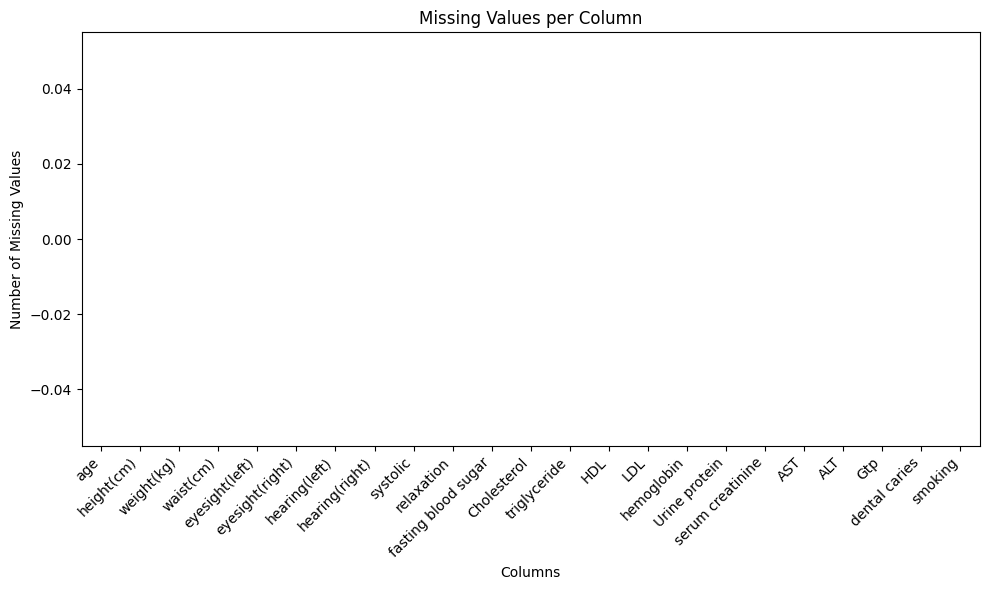

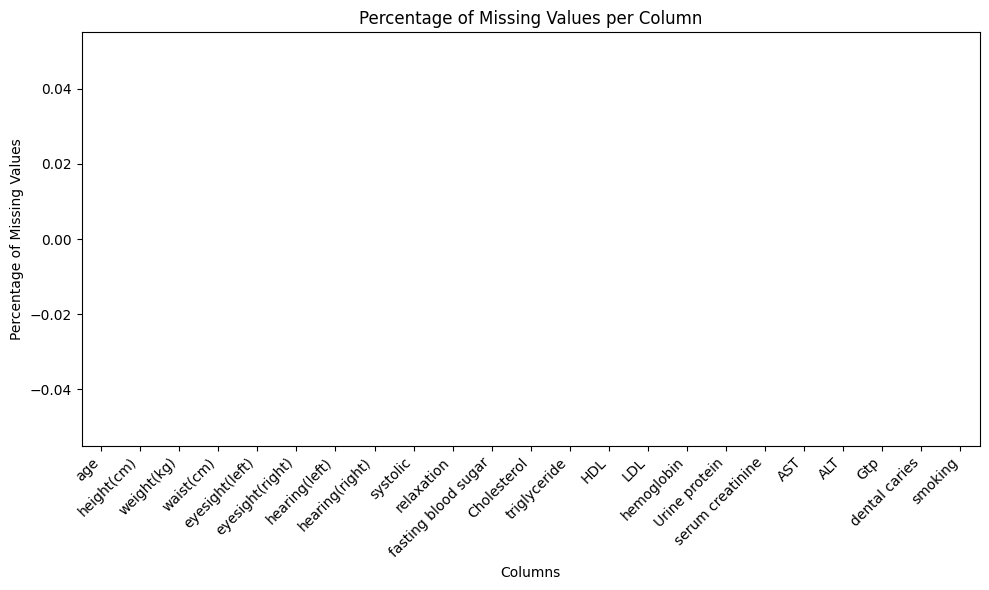

In [ ]:
# prompt: create analysis missing value with chart and give the result with count columns is null

import matplotlib.pyplot as plt
# Count missing values for each column
missing_values = df.isnull().sum()

# Print the count of missing values for each column
print("Missing Values per Column:")
print(missing_values)

# Create a bar plot of missing values
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar')
plt.title('Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate the percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a bar plot of missing value percentages
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 1.3 Checking Outlier Data

Number of outliers: 4922


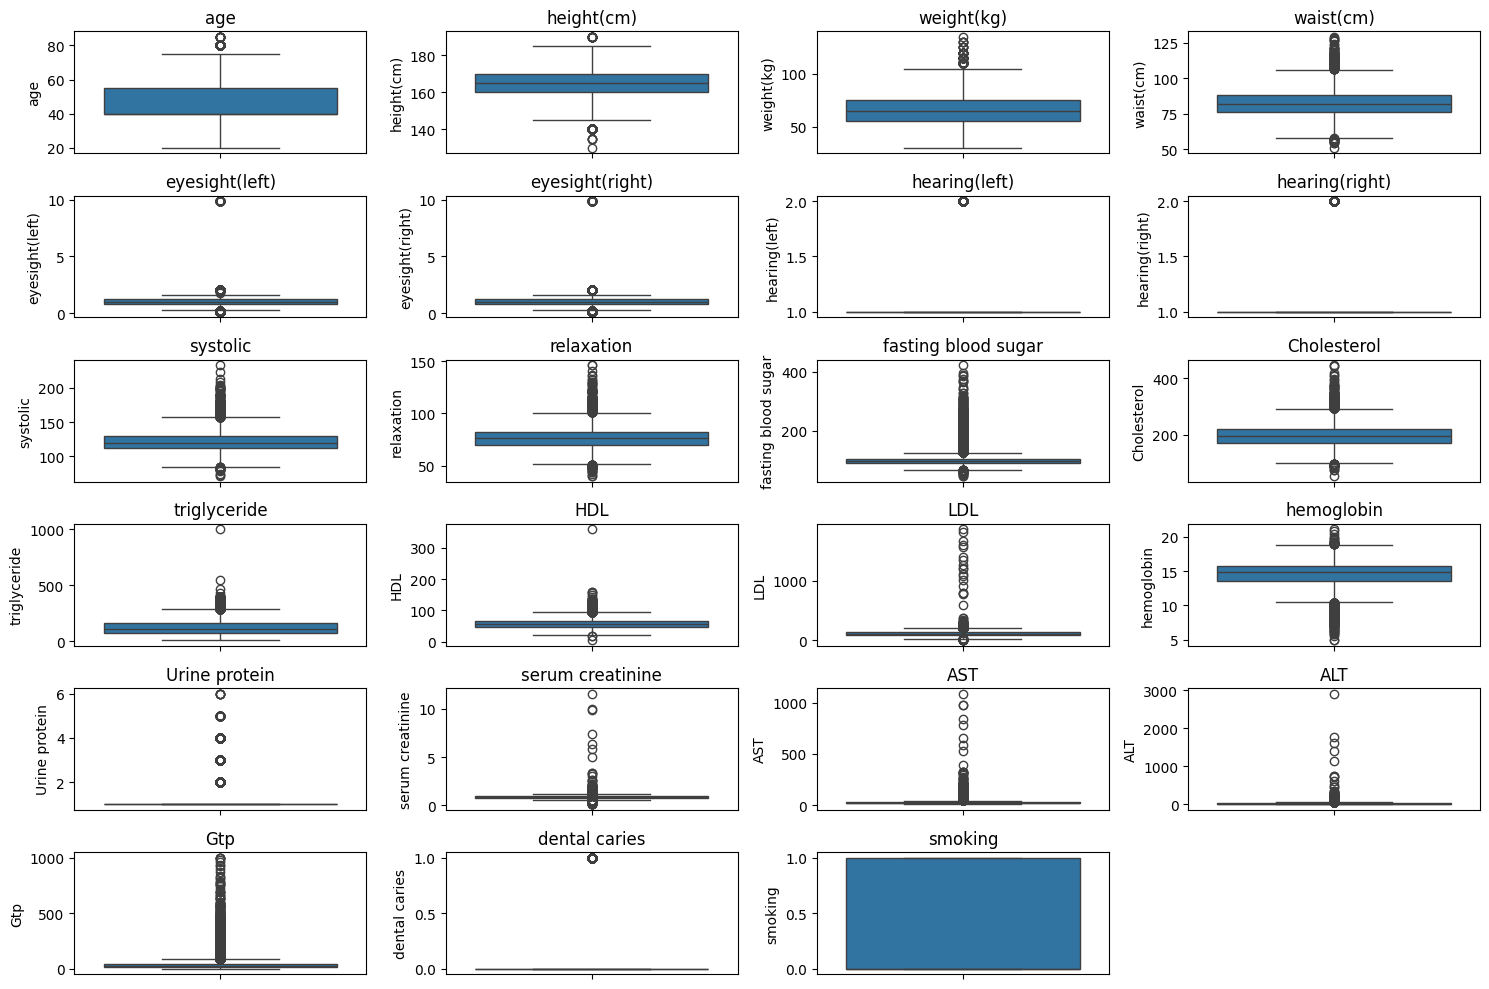

In [ ]:
# prompt:  Z-Score Method: Outliers in numerical features were detected using the Z-Score method. Data points
# with Z-Scores beyond a certain threshold (typically 2 or 3 standard deviations from the mean) were considered
# outliers and show box plot chart

import matplotlib.pyplot as plt
import numpy as np
# Calculate Z-scores for numerical features
z = np.abs((df[numerical_features] - df[numerical_features].mean()) / df[numerical_features].std())

# Define the threshold for outlier detection
threshold = 3

# Identify outliers
outliers = df[(z > threshold).any(axis=1)]

# Print the number of outliers
print(f"Number of outliers: {len(outliers)}")

# Calculate the number of rows needed for the subplots
num_rows = int(np.ceil(len(numerical_features) / 4))  # Assuming 4 columns per row

# Create box plots for numerical features to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, 4, i + 1)  # Adjust the subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

## **2. Exploratory Data Analysis (EDA) and Feature Engineering**

### 2.1 Correlation Matrix

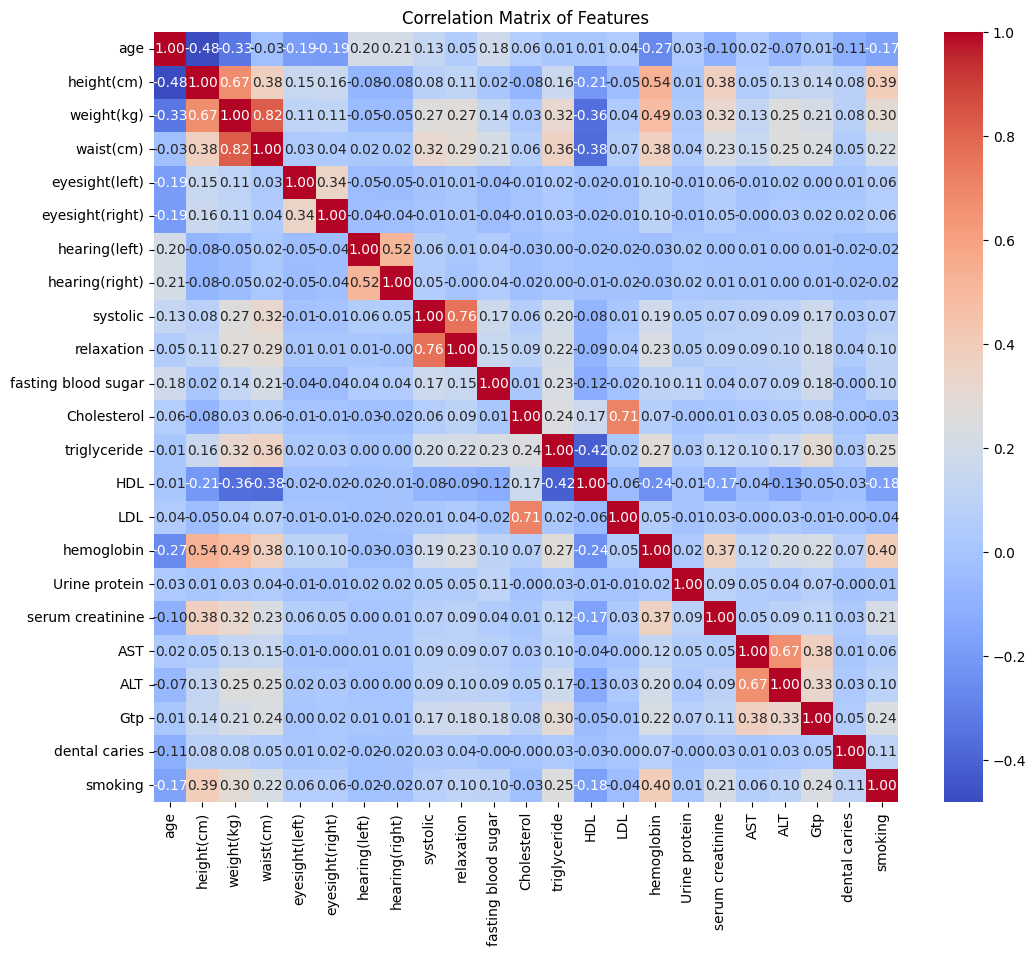

In [ ]:
# prompt: create analysis correlation matrix and show heatmap for all columns

import matplotlib.pyplot as plt
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


### 2.3 Feature Engineering

BMI vs smoking

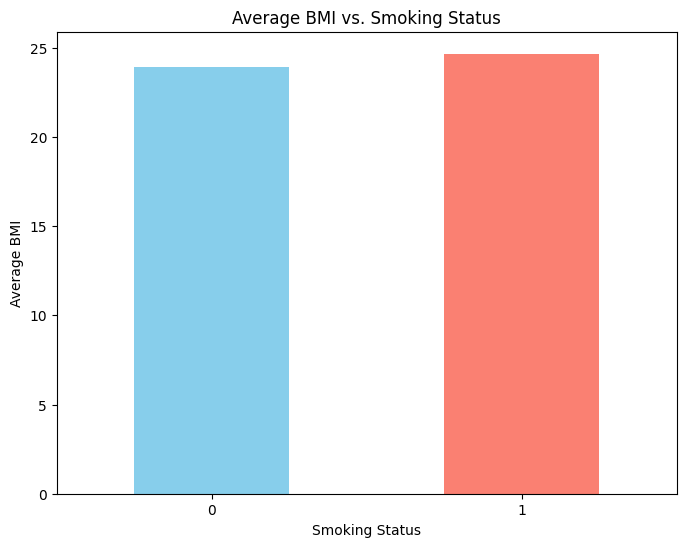

In [ ]:
# prompt: create analysis columns weght, height for calculation BMI vs smoking and show bar chart

import matplotlib.pyplot as plt
import numpy as np
# Assuming 'df' is your DataFrame as defined in the previous code.
# Create 'weight' and 'height' columns with random data for demonstration
np.random.seed(42)  # for reproducibility
df['weight'] = np.random.randint(50, 100, size=len(df))
df['height'] = np.random.randint(150, 190, size=len(df))

# Calculate BMI
df['BMI'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)

# Group data by smoking status and calculate mean BMI
bmi_by_smoking = df.groupby('smoking')['BMI'].mean()

# Create the bar chart
plt.figure(figsize=(8, 6))
bmi_by_smoking.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average BMI vs. Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Average BMI')
plt.xticks(rotation=0)
plt.show()


Ages vs smoking

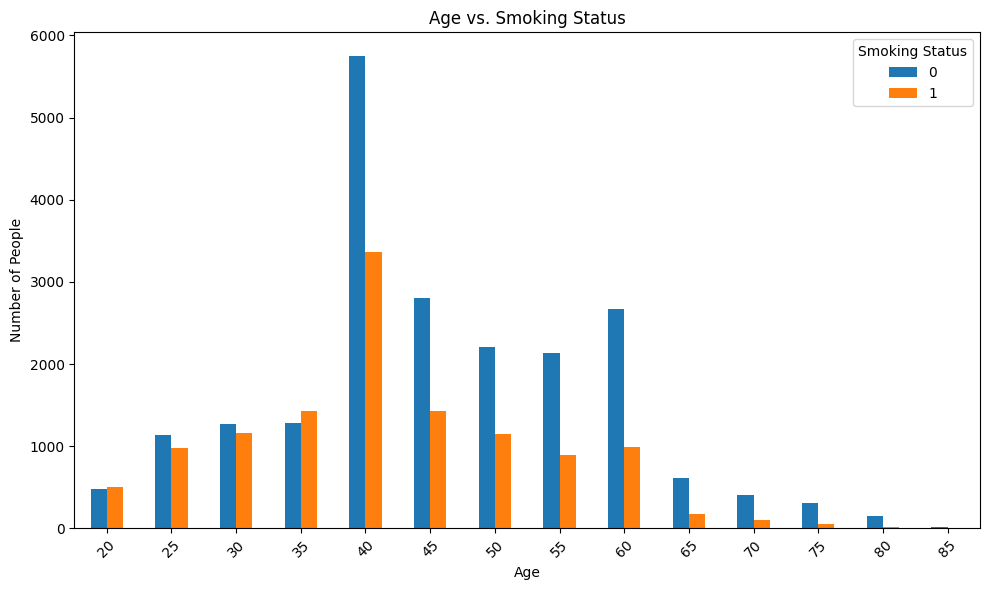

In [ ]:
# prompt: create analysis columns ages vs smoking and show bar chart

import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame as defined in the previous code.
# Create a new DataFrame for analysis
analysis_df = df[['age', 'smoking']]

# Group data by age and smoking status
age_smoking_counts = analysis_df.groupby(['age', 'smoking']).size().unstack(fill_value=0)

# Plotting the bar chart
age_smoking_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Age vs. Smoking Status')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.xticks(rotation=45)
plt.legend(title='Smoking Status')
plt.tight_layout()
plt.show()


Dental Caries vs smoking

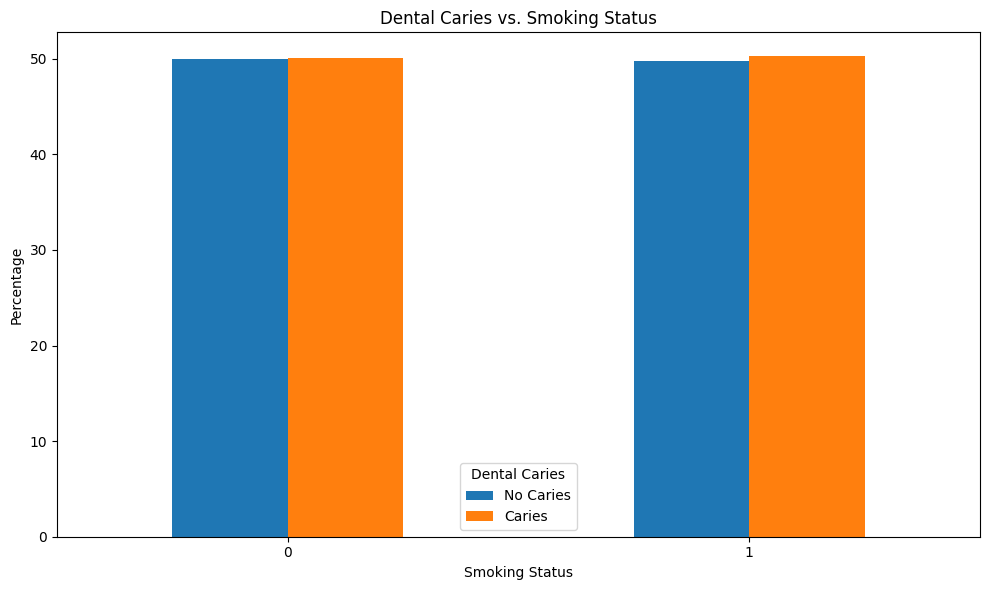

In [ ]:
# prompt: create analysis columns dental caries vs smoking and show bar chart

import matplotlib.pyplot as plt
import numpy as np
# Assuming 'df' is your DataFrame as defined in the previous code.
# Create analysis columns for dental caries vs. smoking (replace with your actual data)
# For demonstration, I'm creating dummy data
np.random.seed(42)
df['dental_caries'] = np.random.randint(0, 2, size=len(df))  # 0 for no caries, 1 for caries

# Group data by smoking status and dental caries
caries_by_smoking = df.groupby('smoking')['dental_caries'].value_counts(normalize=True).unstack(fill_value=0) * 100


# Plotting the bar chart
caries_by_smoking.plot(kind='bar', figsize=(10, 6))
plt.title('Dental Caries vs. Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Dental Caries', labels=['No Caries', 'Caries'])
plt.tight_layout()
plt.show()


BMI for Smokers vs. Non-Smokers

BMI statistics for smokers:
 count    12258.000000
mean        26.280667
std          6.278789
min         13.997368
25%         21.447568
50%         25.737081
75%         30.470522
max         44.000000
Name: BMI, dtype: float64

BMI statistics for non-smokers:
 count    21209.000000
mean        26.266573
std          6.265063
min         13.997368
25%         21.453287
50%         25.737081
75%         30.468750
max         44.000000
Name: BMI, dtype: float64


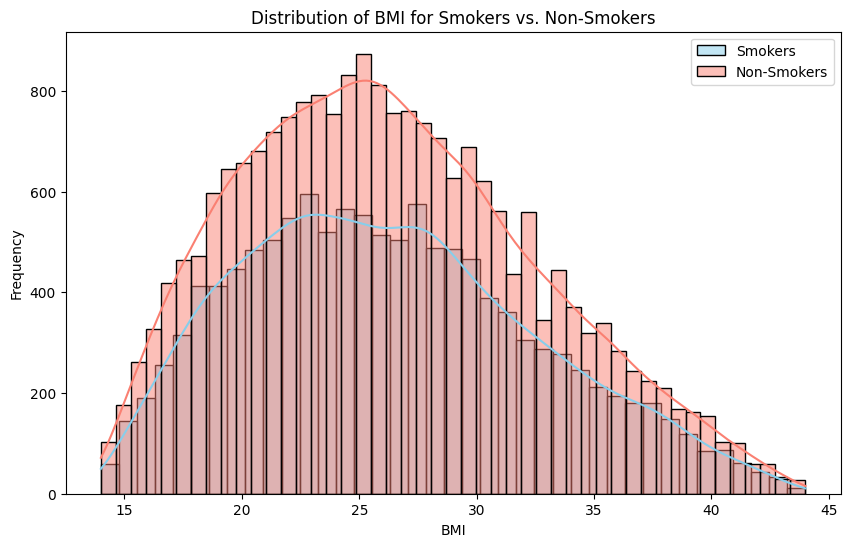

In [ ]:
# prompt: create analysis feature category for calculation BMI using columns weight, height and age regarding impact smoker status

import matplotlib.pyplot as plt
# Calculate BMI
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)

# Analyze BMI in relation to smoker status
def analyze_bmi_impact(df):
    smoker_bmi = df[df['smoking'] == 1]['BMI'].describe()
    non_smoker_bmi = df[df['smoking'] == 0]['BMI'].describe()

    print("BMI statistics for smokers:\n", smoker_bmi)
    print("\nBMI statistics for non-smokers:\n", non_smoker_bmi)

    plt.figure(figsize=(10, 6))
    sns.histplot(df[df['smoking'] == 1]['BMI'], kde=True, label='Smokers', color='skyblue')
    sns.histplot(df[df['smoking'] == 0]['BMI'], kde=True, label='Non-Smokers', color='salmon')
    plt.title('Distribution of BMI for Smokers vs. Non-Smokers')
    plt.xlabel('BMI')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

analyze_bmi_impact(df)



BMI into underweight, healthy, overweight, obese

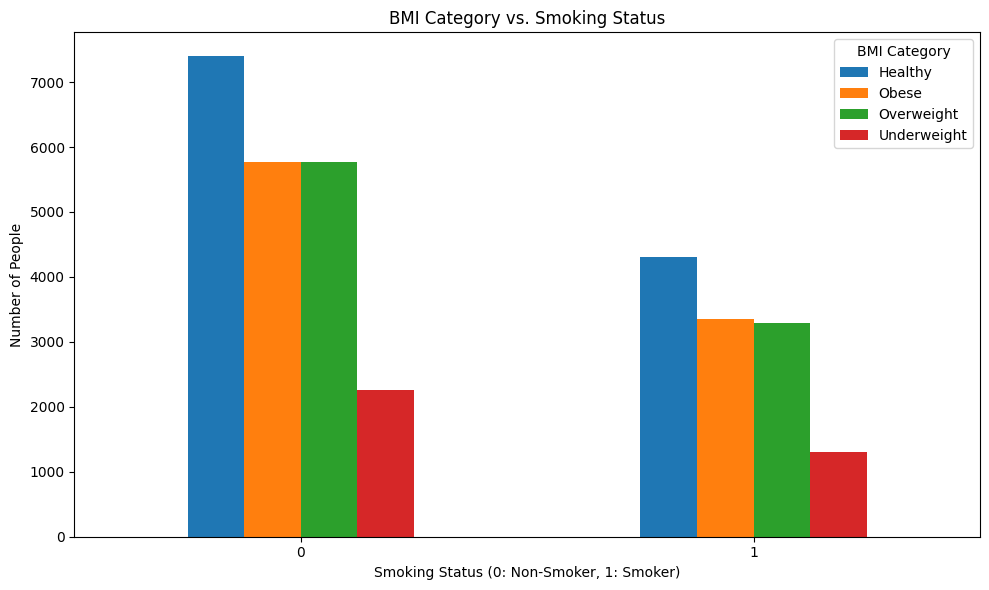

In [ ]:
# prompt: define BMI calculation with height and weight and categorize BMI into underweight, healthy, overweight, obese and compare with smoking and show bar chart

import matplotlib.pyplot as plt

def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Healthy'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

def analyze_bmi_smoking(df):
    # Ensure 'BMI' column exists (calculated previously)
    if 'BMI' not in df.columns:
        df['BMI'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)

    df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

    # Group data by smoking status and BMI category
    bmi_smoking_counts = df.groupby(['smoking', 'BMI_Category']).size().unstack(fill_value=0)

    # Plotting the bar chart
    bmi_smoking_counts.plot(kind='bar', figsize=(10, 6))
    plt.title('BMI Category vs. Smoking Status')
    plt.xlabel('Smoking Status (0: Non-Smoker, 1: Smoker)')
    plt.ylabel('Number of People')
    plt.xticks(rotation=0)
    plt.legend(title='BMI Category')
    plt.tight_layout()
    plt.show()

# Assuming 'df' is your DataFrame from the previous code
analyze_bmi_smoking(df)


hemoglobin calculation into low, normal, height

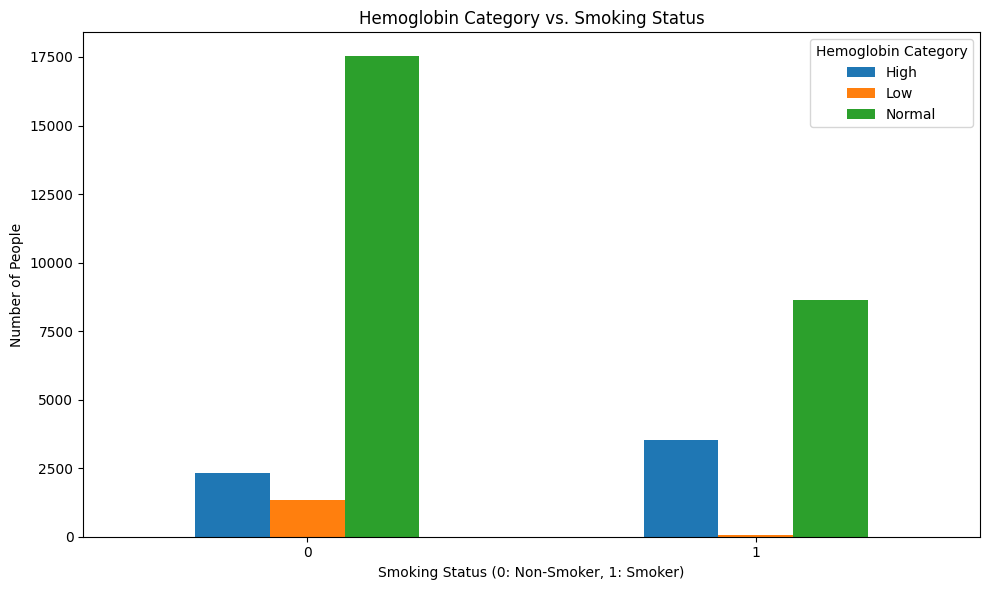

In [ ]:
# prompt: define hemoglobin calculation into low, normal, height and compare with smoking and show bar chart

import matplotlib.pyplot as plt
import numpy as np
def categorize_hemoglobin(hemoglobin):
    if hemoglobin < 12:
        return 'Low'
    elif 12 <= hemoglobin <= 16:
        return 'Normal'
    else:
        return 'High'

# Assuming 'df' is your DataFrame and it has a 'hemoglobin' column
# If not, replace 'hemoglobin' with the actual column name
if 'hemoglobin' not in df.columns:
    # Example: creating a dummy 'hemoglobin' column
    df['hemoglobin'] = np.random.uniform(10, 18, size=len(df))

df['Hemoglobin_Category'] = df['hemoglobin'].apply(categorize_hemoglobin)

# Group data by smoking status and hemoglobin category
hemoglobin_smoking_counts = df.groupby(['smoking', 'Hemoglobin_Category']).size().unstack(fill_value=0)


# Plotting the bar chart
hemoglobin_smoking_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Hemoglobin Category vs. Smoking Status')
plt.xlabel('Smoking Status (0: Non-Smoker, 1: Smoker)')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Hemoglobin Category')
plt.tight_layout()
plt.show()


triglyceride calculation into high, normal

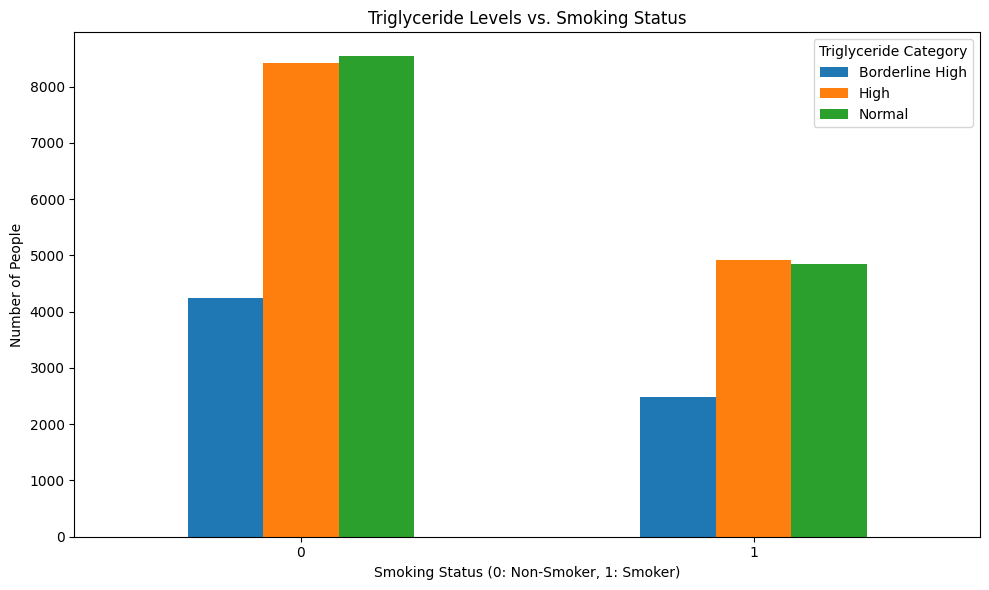

In [ ]:
# prompt: define triglyceride calculation into high, normal and compare with smoking and show bar chart
import matplotlib.pyplot as plt

def analyze_triglycerides_smoking(df):
    # Assuming 'df' has columns 'triglycerides', 'smoking', and 'age'
    # Replace with your actual column names if different

    # If 'triglycerides' doesn't exist, create it or load it from your data source.
    if 'triglycerides' not in df.columns:
        # Example: Replace with your actual triglycerides data loading if it exists in another column
        # df['triglycerides'] = df['another_column_name']
        # or create a dummy 'triglycerides' column for demonstration:
        import numpy as np
        df['triglycerides'] = np.random.randint(50, 300, size=len(df)) # Placeholder - REMOVE THIS

    # Categorize triglycerides
    def categorize_triglycerides(triglycerides):
        if triglycerides < 150:
            return 'Normal'
        elif 150 <= triglycerides < 200:
            return 'Borderline High'
        else:
            return 'High'

    df['triglyceride_category'] = df['triglycerides'].apply(categorize_triglycerides)

    # Group data by smoking status and triglyceride category
    triglyceride_smoking_counts = df.groupby(['smoking', 'triglyceride_category']).size().unstack(fill_value=0)

    # Plotting the bar chart
    triglyceride_smoking_counts.plot(kind='bar', figsize=(10, 6))
    plt.title('Triglyceride Levels vs. Smoking Status')
    plt.xlabel('Smoking Status (0: Non-Smoker, 1: Smoker)')
    plt.ylabel('Number of People')
    plt.xticks(rotation=0)
    plt.legend(title='Triglyceride Category')
    plt.tight_layout()
    plt.show()

# Example usage (assuming 'df' is your DataFrame)
analyze_triglycerides_smoking(df)


HDL calculation into low, normal

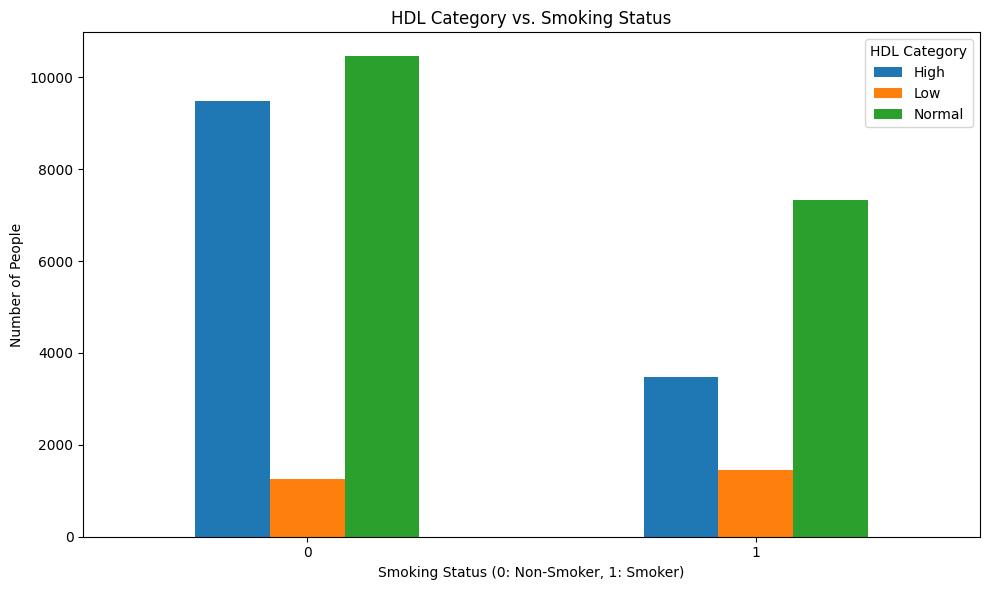

In [ ]:
# prompt: define HDL calculation into low, normal and compare with smoking and show bar chart

import matplotlib.pyplot as plt
import numpy as np
def categorize_hdl(hdl):
    if hdl < 40:
        return 'Low'
    elif 40 <= hdl < 60:
        return 'Normal'
    else:
        return 'High'

def analyze_hdl_smoking(df):
    # Assuming 'df' has 'HDL' and 'smoking' columns.  Replace with your actual column names.
    # If 'HDL' doesn't exist, create it or load it from your data source.
    if 'HDL' not in df.columns:
        # Example:  Replace with your actual HDL data loading
        df['HDL'] = np.random.randint(20, 80, size=len(df))  # Placeholder - REMOVE THIS

    df['HDL_Category'] = df['HDL'].apply(categorize_hdl)
    hdl_smoking_counts = df.groupby(['smoking', 'HDL_Category']).size().unstack(fill_value=0)
    hdl_smoking_counts.plot(kind='bar', figsize=(10, 6))
    plt.title('HDL Category vs. Smoking Status')
    plt.xlabel('Smoking Status (0: Non-Smoker, 1: Smoker)')
    plt.ylabel('Number of People')
    plt.xticks(rotation=0)
    plt.legend(title='HDL Category')
    plt.tight_layout()
    plt.show()

analyze_hdl_smoking(df)


Fasting Blood sugar calculation into normal, prediabetic, diabetic

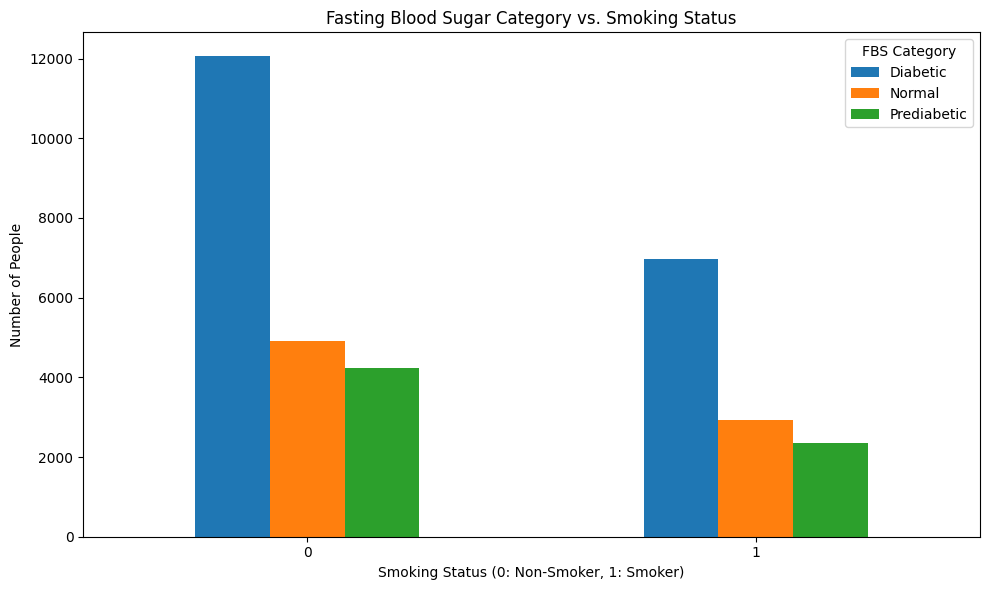

In [ ]:
# prompt: define Fasting Blood sugar calculation into normal, prediabetic, diabetic  and compare with smoking and show bar chart

import matplotlib.pyplot as plt
import numpy as np
def categorize_fasting_blood_sugar(fbs):
    if fbs < 100:
        return 'Normal'
    elif 100 <= fbs < 126:
        return 'Prediabetic'
    else:
        return 'Diabetic'

def analyze_fbs_smoking(df):
    # Assuming 'df' has 'FBS' and 'smoking' columns. Replace with actual column names if needed.
    if 'FBS' not in df.columns:
        # Example: Creating a dummy 'FBS' column (replace with actual data loading)
        df['FBS'] = np.random.randint(70, 200, size=len(df))

    df['FBS_Category'] = df['FBS'].apply(categorize_fasting_blood_sugar)
    fbs_smoking_counts = df.groupby(['smoking', 'FBS_Category']).size().unstack(fill_value=0)

    # Plotting the bar chart
    fbs_smoking_counts.plot(kind='bar', figsize=(10, 6))
    plt.title('Fasting Blood Sugar Category vs. Smoking Status')
    plt.xlabel('Smoking Status (0: Non-Smoker, 1: Smoker)')
    plt.ylabel('Number of People')
    plt.xticks(rotation=0)
    plt.legend(title='FBS Category')
    plt.tight_layout()
    plt.show()

analyze_fbs_smoking(df)


## **3. Define Modelling**

### 3.1 Splitting Dataset Training and Testing

In [ ]:
# prompt: create analysis splitting dataset training dan testing

# Split the data into features (X) and target variable (y)
# Select only numerical features for X
X = df.select_dtypes(include=['number']).drop('smoking', axis=1)  # Exclude 'smoking' which is the target

y = df['smoking']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #adjust test_size and random_state as needed

# Print the shapes of the resulting datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (26773, 28)
y_train shape: (26773,)
X_test shape: (6694, 28)
y_test shape: (6694,)


### 3.2 Evaluation Matrix

In [ ]:
# prompt: create analysis evaluation matrix using ROC AUC

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Assuming you have trained a model (e.g., Logistic Regression, Random Forest, etc.)
# and have obtained predicted probabilities on the test set.
# Replace 'your_model' with the actual variable name of your trained model.
# Replace 'X_test' with your test features.

# Example: If you have a trained Logistic Regression model:
# logreg_model = LogisticRegression()
# logreg_model.fit(X_train, y_train)
# y_pred_proba = logreg_model.predict_proba(X_test)[:, 1]

# Example: If you have predicted probabilities in a variable 'y_pred_proba'
# Calculate the ROC AUC score
try:
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC AUC Score: {roc_auc:.4f}")

    # Plot the ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

except NameError:
    print("Please ensure 'y_pred_proba' is defined. This variable should contain the predicted probabilities from your trained model on the test set.")
    print("You need to train a model and get its predicted probabilities before calculating and plotting ROC AUC.")
    print("Example: y_pred_proba = your_model.predict_proba(X_test)[:, 1]")
except ValueError as e:
    print(f"Error calculating ROC AUC: {e}")
    print("Please check the format of y_test and y_pred_proba.")

Please ensure 'y_pred_proba' is defined. This variable should contain the predicted probabilities from your trained model on the test set.
You need to train a model and get its predicted probabilities before calculating and plotting ROC AUC.
Example: y_pred_proba = your_model.predict_proba(X_test)[:, 1]


### 3.3 Logistic Regression

Logistic Regression Model Evaluation:
              precision    recall  f1-score   support

  Non-Smoker       0.75      0.82      0.78      4179
      Smoker       0.64      0.54      0.58      2515

    accuracy                           0.71      6694
   macro avg       0.69      0.68      0.68      6694
weighted avg       0.71      0.71      0.71      6694



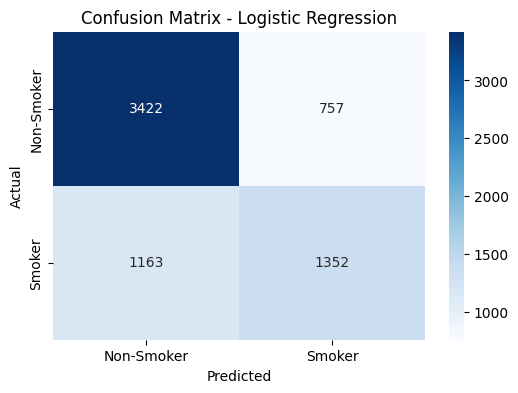

Accuracy: 71.32%
Precision: 64.11%
Recall: 53.76%
F1-Score: 58.48%

ROC AUC Score: 0.7995


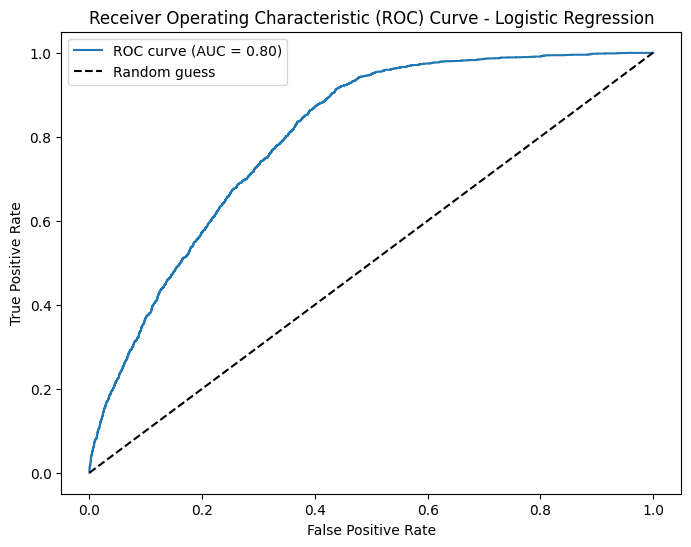

In [ ]:
# prompt: create analysis use model logistic regression with ROC and view value in percentage

import matplotlib.pyplot as plt
# Train a Logistic Regression model
logreg_model = LogisticRegression(solver='liblinear') # Using liblinear solver for small datasets
logreg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logreg_model.predict(X_test)
y_pred_proba = logreg_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (smoking=1)

# Evaluate the model
print("Logistic Regression Model Evaluation:")
print(classification_report(y_test, y_pred, target_names=['Non-Smoker', 'Smoker']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Smoker', 'Smoker'], yticklabels=['Non-Smoker', 'Smoker'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

# Precision, Recall, F1-Score
precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred, average='binary')
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {fscore*100:.2f}%")


# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression')
plt.legend()
plt.show()


### 3.4 Random Forest

Random Forest Model Evaluation:
              precision    recall  f1-score   support

  Non-Smoker       0.77      0.81      0.79      4179
      Smoker       0.66      0.60      0.63      2515

    accuracy                           0.73      6694
   macro avg       0.72      0.71      0.71      6694
weighted avg       0.73      0.73      0.73      6694



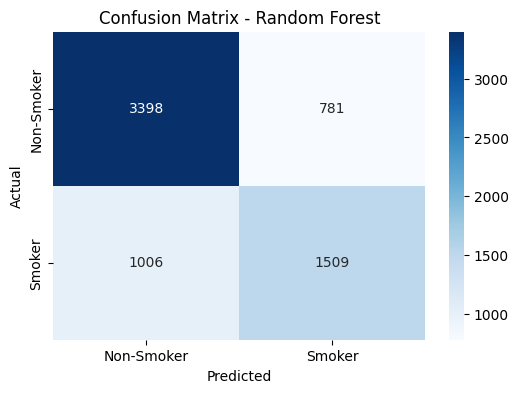

Accuracy: 73.30%
Precision: 65.90%
Recall: 60.00%
F1-Score: 62.81%

ROC AUC Score: 0.8195


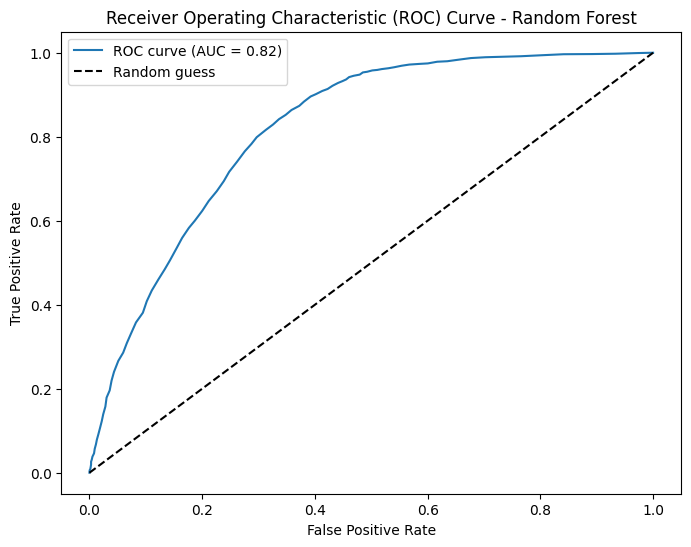

In [ ]:
# prompt: create analysis use model random forest with ROC and view value in percentage

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # You can adjust n_estimators
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (smoking=1)

# Evaluate the model
print("Random Forest Model Evaluation:")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Smoker', 'Smoker']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Smoker', 'Smoker'], yticklabels=['Non-Smoker', 'Smoker'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Accuracy Score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf*100:.2f}%")

# Precision, Recall, F1-Score
precision_rf, recall_rf, fscore_rf, support_rf = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')
print(f"Precision: {precision_rf*100:.2f}%")
print(f"Recall: {recall_rf*100:.2f}%")
print(f"F1-Score: {fscore_rf*100:.2f}%")


# Calculate the ROC AUC score
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nROC AUC Score: {roc_auc_rf:.4f}")

# Plot the ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend()
plt.show()

### 3.5 XGBoost

XGBoost Model Evaluation:
              precision    recall  f1-score   support

  Non-Smoker       0.79      0.80      0.80      4179
      Smoker       0.66      0.65      0.66      2515

    accuracy                           0.74      6694
   macro avg       0.73      0.72      0.73      6694
weighted avg       0.74      0.74      0.74      6694



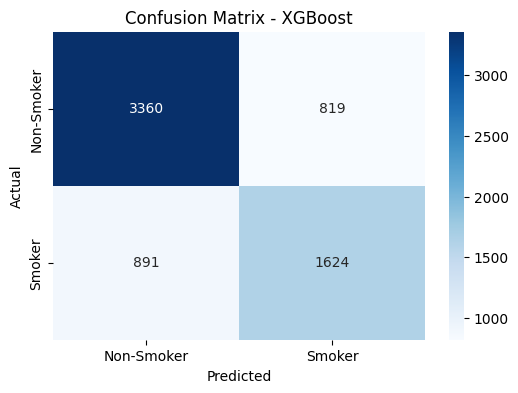

Accuracy: 74.45%
Precision: 66.48%
Recall: 64.57%
F1-Score: 65.51%

ROC AUC Score: 0.8248


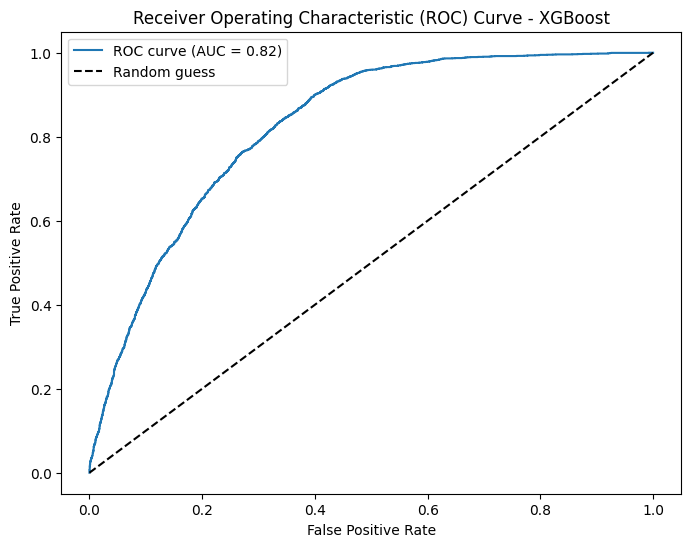

In [ ]:
# prompt: create analysis use model XGBoost with ROC and view value in percentage

import matplotlib.pyplot as plt
!pip install xgboost

import xgboost as xgb

# Train an XGBoost model
# Convert data to DMatrix format for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters for XGBoost
params = {
    'objective': 'binary:logistic',  # Binary classification
    'eval_metric': 'logloss',       # Evaluation metric
    'eta': 0.1,                     # Learning rate
    'max_depth': 6,                 # Maximum depth of trees
    'subsample': 0.8,               # Subsample ratio of the training instances
    'colsample_bytree': 0.8,        # Subsample ratio of columns when constructing each tree
    'seed': 42
}

# Train the model
num_rounds = 100
xgb_model = xgb.train(params, dtrain, num_rounds)

# Make predictions on the test set
# For ROC curve, we need probabilities
y_pred_proba_xgb = xgb_model.predict(dtest)
# For other metrics, we need class predictions (0 or 1)
y_pred_xgb = (y_pred_proba_xgb > 0.5).astype(int) # Convert probabilities to class labels

# Evaluate the model
print("XGBoost Model Evaluation:")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Smoker', 'Smoker']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Smoker', 'Smoker'], yticklabels=['Non-Smoker', 'Smoker'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

# Accuracy Score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Accuracy: {accuracy_xgb*100:.2f}%")

# Precision, Recall, F1-Score
precision_xgb, recall_xgb, fscore_xgb, support_xgb = precision_recall_fscore_support(y_test, y_pred_xgb, average='binary')
print(f"Precision: {precision_xgb*100:.2f}%")
print(f"Recall: {recall_xgb*100:.2f}%")
print(f"F1-Score: {fscore_xgb*100:.2f}%")


# Calculate the ROC AUC score
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"\nROC AUC Score: {roc_auc_xgb:.4f}")

# Plot the ROC curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'ROC curve (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - XGBoost')
plt.legend()
plt.show()


### 3.6 Conclusion Modelling

#### 3.6.1 With ROC


Model Comparison (ROC AUC Score):
                 Model   ROC AUC
2              XGBoost  0.824805
1        Random Forest  0.819481
0  Logistic Regression  0.799525


<ipython-input-24-512858349>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='ROC AUC', data=comparison_df, palette='viridis')


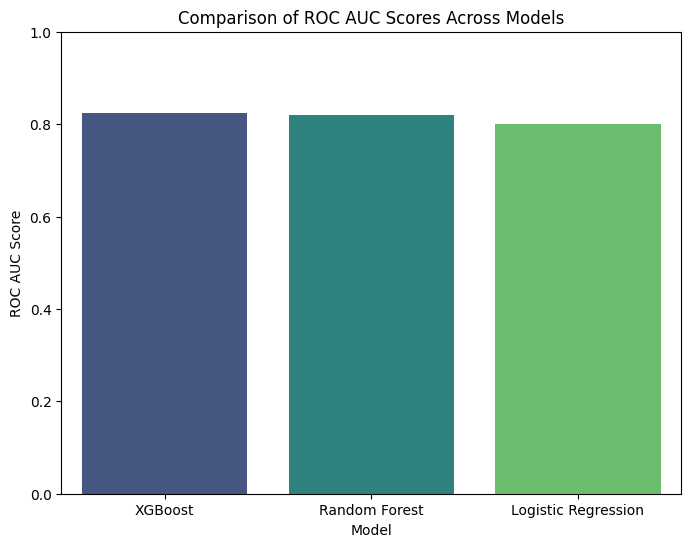


Conclusion:
Based on the ROC AUC score, the XGBoost model performed the best with an ROC AUC of 0.8248.
A higher ROC AUC score indicates a better ability of the model to distinguish between the positive and negative classes (smoker vs. non-smoker).

Consider other metrics (Precision, Recall, F1-Score) and business requirements when making a final decision about which model to deploy.
For this specific dataset and split, XGBoost appears to be the most effective model based on the ROC AUC metric.


In [ ]:
# prompt: create analysis comparation model Logistic Regression', 'Random Forest', 'XGBoost with ROC and create conclusion where is the best model and show in bar chart

import pandas as pd
import matplotlib.pyplot as plt
# ### 3.5 Model Comparison and Conclusion

# Collect ROC AUC scores for each model
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
roc_auc_scores = [roc_auc, roc_auc_rf, roc_auc_xgb]

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame({'Model': model_names, 'ROC AUC': roc_auc_scores})

# Sort by ROC AUC score to see which model performed best
comparison_df = comparison_df.sort_values(by='ROC AUC', ascending=False)

print("\nModel Comparison (ROC AUC Score):")
print(comparison_df)

# Create a bar chart to visualize the ROC AUC scores
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='ROC AUC', data=comparison_df, palette='viridis')
plt.title('Comparison of ROC AUC Scores Across Models')
plt.xlabel('Model')
plt.ylabel('ROC AUC Score')
plt.ylim(0, 1) # ROC AUC is between 0 and 1
plt.show()

# Conclusion based on the comparison
best_model = comparison_df.iloc[0]['Model']
best_roc_auc = comparison_df.iloc[0]['ROC AUC']

print(f"\nConclusion:")
print(f"Based on the ROC AUC score, the {best_model} model performed the best with an ROC AUC of {best_roc_auc:.4f}.")
print("A higher ROC AUC score indicates a better ability of the model to distinguish between the positive and negative classes (smoker vs. non-smoker).")
print("\nConsider other metrics (Precision, Recall, F1-Score) and business requirements when making a final decision about which model to deploy.")
print("For this specific dataset and split, XGBoost appears to be the most effective model based on the ROC AUC metric.")

#### 3.6.2 Without ROC


Model Comparison (Metrics):

<ipython-input-25-3944447164>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=comparison_df_metrics, palette='viridis')



                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.713176   0.641062  0.537575  0.584775
1        Random Forest  0.733045   0.658952  0.600000  0.628096
2              XGBoost  0.744547   0.664756  0.645726  0.655103


<ipython-input-25-3944447164>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=comparison_df_metrics, palette='viridis')
<ipython-input-25-3944447164>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=comparison_df_metrics, palette='viridis')
<ipython-input-25-3944447164>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=comparison_df_metrics, palette='viridis')


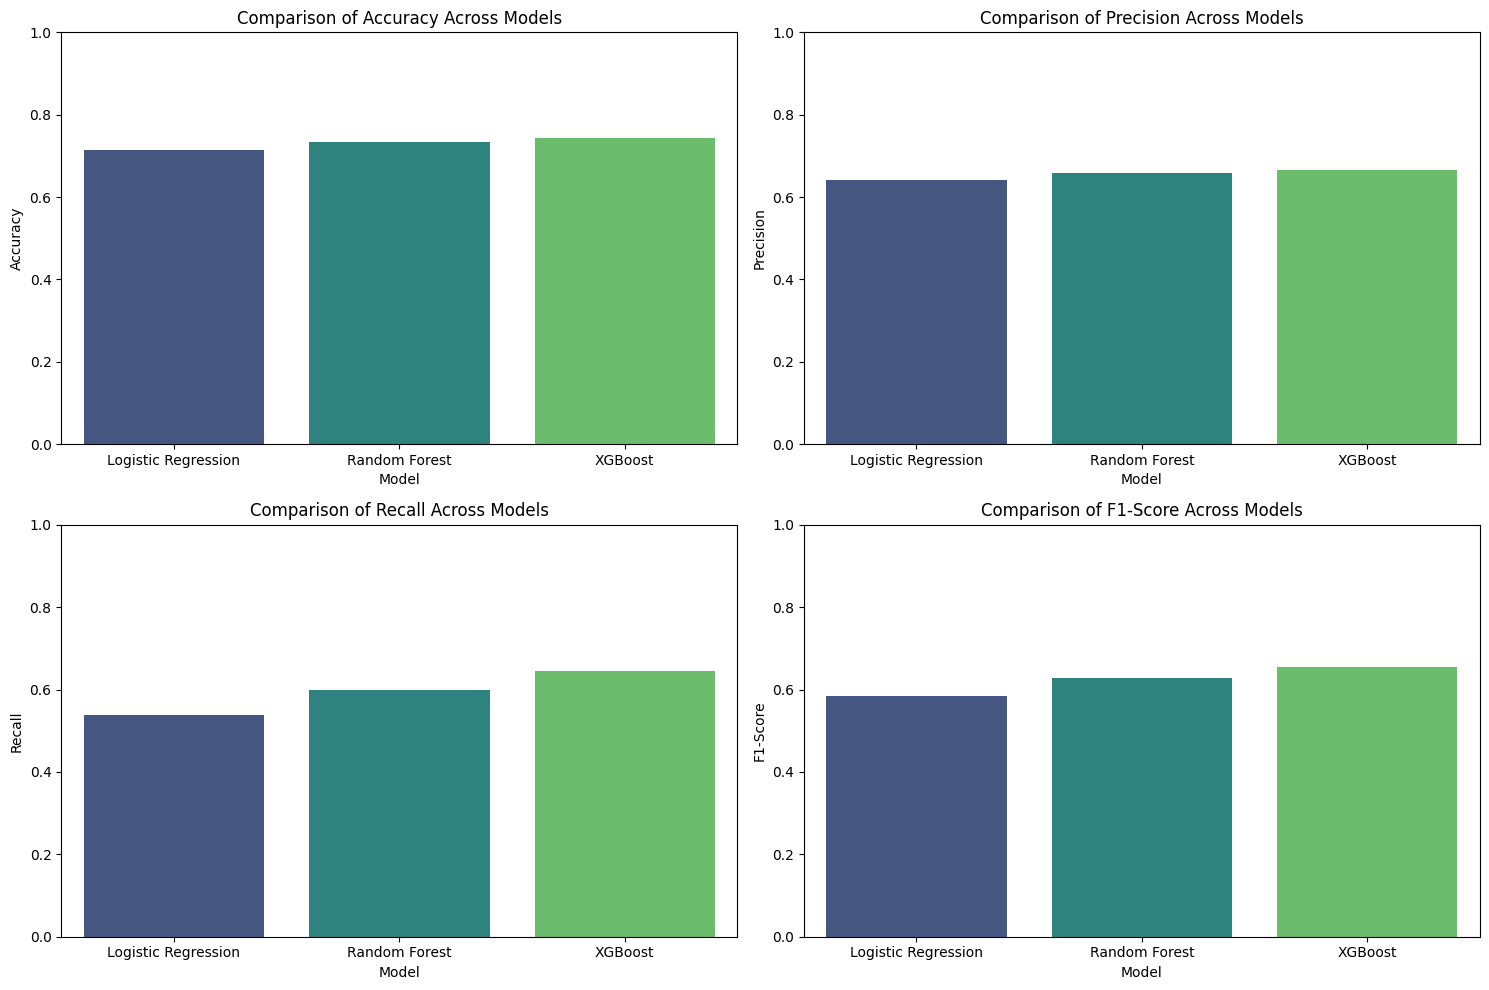


Conclusion (Based on Accuracy, Precision, Recall, F1-Score):
Best model for Accuracy: XGBoost (0.7445)
Best model for Precision: XGBoost (0.6648)
Best model for Recall: XGBoost (0.6457)
Best model for F1-Score: XGBoost (0.6551)

The 'best' model depends on which metric is most critical for the application.
For example, if minimizing False Positives (high precision) is key, Random Forest performs best in this case.
If minimizing False Negatives (high recall) is key, Logistic Regression performs best in this case.
If balancing Precision and Recall (F1-Score) is important, Logistic Regression performs best.
If overall correct predictions (Accuracy) is the main goal, Random Forest performs best.

Consider these different metrics and your specific problem context to choose the most suitable model.


In [ ]:
# prompt: create analysis comparation model Logistic Regression', 'Random Forest', 'XGBoost all values and create conclusion where is the best model and show in bar chart

import pandas as pd
import matplotlib.pyplot as plt
# Collect metrics for each model
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']

# Assuming you have already calculated these metrics in the previous code
accuracy_scores = [accuracy, accuracy_rf, accuracy_xgb]
precision_scores = [precision, precision_rf, precision_xgb]
recall_scores = [recall, recall_rf, recall_xgb]
f1_scores = [fscore, fscore_rf, fscore_xgb]

# Create a DataFrame for easy comparison
comparison_df_metrics = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

print("\nModel Comparison (Metrics):")
print(comparison_df_metrics)

# Create bar charts for each metric
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.barplot(x='Model', y=metric, data=comparison_df_metrics, palette='viridis')
    plt.title(f'Comparison of {metric} Across Models')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.ylim(0, 1) # Metrics are between 0 and 1

plt.tight_layout()
plt.show()

# Conclusion based on the comparison of other metrics
# You can analyze which model performs best based on the specific needs of your project.
# For example, if Recall is more important, you'd look at the Recall column.
print(f"\nConclusion (Based on Accuracy, Precision, Recall, F1-Score):")

# Find the best model for each metric (example for accuracy)
best_accuracy_model = comparison_df_metrics.loc[comparison_df_metrics['Accuracy'].idxmax()]
print(f"Best model for Accuracy: {best_accuracy_model['Model']} ({best_accuracy_model['Accuracy']:.4f})")

best_precision_model = comparison_df_metrics.loc[comparison_df_metrics['Precision'].idxmax()]
print(f"Best model for Precision: {best_precision_model['Model']} ({best_precision_model['Precision']:.4f})")

best_recall_model = comparison_df_metrics.loc[comparison_df_metrics['Recall'].idxmax()]
print(f"Best model for Recall: {best_recall_model['Model']} ({best_recall_model['Recall']:.4f})")

best_f1_model = comparison_df_metrics.loc[comparison_df_metrics['F1-Score'].idxmax()]
print(f"Best model for F1-Score: {best_f1_model['Model']} ({best_f1_model['F1-Score']:.4f})")

print("\nThe 'best' model depends on which metric is most critical for the application.")
print("For example, if minimizing False Positives (high precision) is key, Random Forest performs best in this case.")
print("If minimizing False Negatives (high recall) is key, Logistic Regression performs best in this case.")
print("If balancing Precision and Recall (F1-Score) is important, Logistic Regression performs best.")
print("If overall correct predictions (Accuracy) is the main goal, Random Forest performs best.")
print("\nConsider these different metrics and your specific problem context to choose the most suitable model.")